# CSTR Control via REINFORCE

A neural network policy with a **stochastic Gaussian output** is trained using the REINFORCE
(Monte Carlo policy gradient) algorithm. We warm-start from the SPS solution.

Based on [Chapter 7 of *Machine Learning in Chemical Engineering*](https://edgarsmdn.github.io/MLCE_book/07_RL_Control.html) (Flores-Tlacuahuac et al., 2023).

## 1. Imports

In [1]:
from copy import deepcopy
import numpy as np
import torch
import torch.nn as nn
from scipy.integrate import solve_ivp
from pylab import *


## 2. CSTR Model and Problem Setup

Same CSTR, time grid, setpoints, and scaling as the SPS notebook.

In [2]:
def cstr(t, x, Tc):
    Ca, T = x
    q, V    = 100, 100
    Tf, Caf = 350, 1.0
    rho, Cp = 1000, 0.239
    mdelH   = 5e4
    EoverR  = 8750
    k0      = 7.2e10
    UA      = 5e4
    rA    = k0 * np.exp(-EoverR / T) * Ca
    dCadt = q/V * (Caf - Ca) - rA
    dTdt  = q/V * (Tf - T) + mdelH/(rho*Cp) * rA + UA/(V*rho*Cp) * (Tc - T)
    return [dCadt, dTdt]

# Time grid and initial conditions
t  = np.linspace(0, 25, 101)
x0 = np.array([0.8773, 324.5])

# Setpoints
n1 = len(t) // 2
Ca_sp = np.array([0.8]*n1 + [0.9]*(len(t)-n1))
T_sp  = np.array([330.]*n1 + [320.]*(len(t)-n1))

# Control bounds
Tc_lb, Tc_ub = 295, 305

# Scaling
x_mean  = np.array([0.8, 325.,  0.,  0.])
x_range = np.array([0.25, 10., 0.1, 20.])
u_range, u_bias = 10, 295.0
noise = 0.0


## 3. Probabillistic Policy Network

The policy outputs a **mean** $\mu$ and **log-standard-deviation** $\log\sigma$ for a Gaussian
distribution over $T_c$. During training we sample $T_c \sim \mathcal{N}(\mu, \sigma^2)$;
at deployment we use $T_c = \mu$.

$$[c_A, T, e_{c_A}, e_T] \;\longrightarrow\; \boxed{\text{NN}} \;\longrightarrow\; (\mu, \log\sigma) \;\longrightarrow\; T_c \sim \mathcal{N}(\mu, \sigma^2)$$

In [ ]:
class GaussianPolicy(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 8),
            nn.LeakyReLU(0.1),
            nn.Linear(8, 2),
            nn.LeakyReLU(0.1),
        )
        self.mu_head      = nn.Sequential(nn.Linear(2, 1), nn.ReLU6())  # output in [0,6], same as SPS
        self.log_sig_head = nn.Linear(2, 1)

    def forward(self, x):
        h = self.net(x)
        mu      = self.mu_head(h)                  # in [0, 6]
        log_sig = self.log_sig_head(h).clamp(-4, 0)
        return mu, log_sig


def normalise(ca, T, ca_sp, T_sp):
    xk = np.array([ca, T, ca_sp - ca, T_sp - T])
    return torch.tensor((xk - x_mean) / x_range, dtype=torch.float32)


def get_action(pol, ca, T, ca_sp, T_sp, deterministic=False):
    """Sample Tc from the policy distribution (or use mean if deterministic)."""
    obs = normalise(ca, T, ca_sp, T_sp)
    mu, log_sig = pol(obs)
    if deterministic:
        u = mu
    else:
        dist = torch.distributions.Normal(mu, log_sig.exp())
        u = dist.rsample()
    Tc = u.item() * u_range/6 + u_bias  # [0,6] -> [295,305]
    return float(np.clip(Tc, Tc_lb, Tc_ub))


policy = GaussianPolicy()


## 4. Transfer Learning from SPS

We load the SPS-trained weights into the shared trunk of the Gaussian policy.
The $\log\sigma$ head is initialized to a small constant so the policy starts near-deterministic.

In [4]:
import os

sps_weights_file = 'sps_policy.pt'

if os.path.exists(sps_weights_file):
    sps_sd = torch.load(sps_weights_file, weights_only=True)
    policy.net[0].weight.data.copy_(sps_sd['0.weight'])
    policy.net[0].bias.data.copy_(sps_sd['0.bias'])
    policy.net[2].weight.data.copy_(sps_sd['2.weight'])
    policy.net[2].bias.data.copy_(sps_sd['2.bias'])
    policy.mu_head[0].weight.data.copy_(sps_sd['4.weight'])
    policy.mu_head[0].bias.data.copy_(sps_sd['4.bias'])
    print('Transferred all SPS weights to policy (trunk + mu_head)')
else:
    print('SPS weights not found — starting from random initialization')

nn.init.constant_(policy.log_sig_head.weight, 0.0)
nn.init.constant_(policy.log_sig_head.bias, float(np.log(0.1)))
print(f'log_sigma initialized: sigma = 0.1')


Transferred all SPS weights to policy (trunk + mu_head)
log_sigma initialized: sigma = 0.1


## 5. Episode Rollout

Returns the list of log-probabilities and per-step costs needed for the REINFORCE update.

$$G_t = \sum_{k=t}^{T-1} c_k \qquad (\gamma = 1)$$

In [5]:
def rollout(pol, deterministic=False, collect=False):
    x = x0.copy()
    Tc_prev = None
    log_probs, step_costs = [], []
    Ca_hist, T_hist, Tc_hist = [x[0]], [x[1]], []

    for i in range(len(t) - 1):
        obs = normalise(x[0], x[1], Ca_sp[i], T_sp[i])
        mu, log_sig = pol(obs)
        if deterministic:
            u_norm = mu
        else:
            dist = torch.distributions.Normal(mu, log_sig.exp())
            u_norm = dist.rsample().clamp(0, 6)  # clip to valid range before log_prob
            log_probs.append(dist.log_prob(u_norm).squeeze())

        Tc = float(u_norm.item() * u_range/6 + u_bias)  # no further clip needed

        sol = solve_ivp(cstr, [t[i], t[i+1]], x, args=(Tc,))
        x   = sol.y[:, -1]  # no process noise

        e_ca  = abs(Ca_sp[i] - x[0])
        e_T   = abs(T_sp[i]  - x[1])
        u_mag = abs(Tc - Tc_lb) / 100
        u_cha = abs(Tc - Tc_prev) / 100 if Tc_prev is not None else 0.0

        step_costs.append(e_ca/0.2 + e_T/15 + u_mag + u_cha)
        Tc_prev = Tc
        Tc_hist.append(Tc)
        Ca_hist.append(x[0])
        T_hist.append(x[1])

    total_cost = sum(step_costs)
    if collect:
        return total_cost, np.array(Ca_hist), np.array(T_hist), np.array(Tc_hist), np.array(step_costs)
    return log_probs, step_costs, total_cost


## 6. REINFORCE Training

At each iteration:
1. Roll out the current policy to collect $\{\log \pi_\theta(u_t \mid x_t)\}$ and $\{c_t\}$
2. Compute cost-to-go $G_t = \sum_{k \geq t} c_k$
3. Subtract a **running baseline** $b$ (exponential moving average of recent episode costs):

$$A_t = G_t - b$$

4. Update: $\theta \leftarrow \theta - \alpha \sum_t A_t \nabla_\theta \log \pi_\theta(u_t \mid x_t)$

The baseline reduces variance without biasing the gradient (since $\mathbb{E}[\nabla_\theta \log \pi_\theta \cdot b] = 0$).
When $A_t \approx 0$ (episode cost near the running mean) the update is small — the policy is stable near its current performance.

In [6]:
def train_reinforce(pol, n_iter=2000, lr=1e-4, seed=0):
    torch.manual_seed(seed)
    optimizer = torch.optim.Adam(pol.parameters(), lr=lr)
    cost_history = []
    baseline = None  # running mean of episode cost

    for it in range(n_iter):
        log_probs, step_costs, total_cost = rollout(pol)

        # Update exponential moving average baseline
        if baseline is None:
            baseline = total_cost
        else:
            baseline = 0.95 * baseline + 0.05 * total_cost

        # Cost-to-go G_t (suffix sum), baseline-subtracted advantage
        costs_t = torch.tensor(step_costs, dtype=torch.float32)
        G = costs_t.flip(0).cumsum(0).flip(0)  # G[t] = sum_{k>=t} c_k
        A = G - baseline                        # advantage: >0 = worse than average

        # REINFORCE loss: minimise cost -> make high-A actions less likely
        loss = (A * torch.stack(log_probs)).sum()

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(pol.parameters(), 0.1)
        optimizer.step()

        cost_history.append(total_cost)
        if (it+1) % 200 == 0:
            print(f'iter {it+1:4d}  cost = {total_cost:.3f}  baseline = {baseline:.3f}')

    return pol, cost_history


policy, cost_history = train_reinforce(policy, n_iter=2000, lr=1e-4)

iter  200  cost = 31.544  baseline = 135.030


c:\Users\Mikey\Desktop\CHE891_Classwork\py312_env\Lib\site-packages\numpy\linalg\_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
C:\Users\Mikey\AppData\Local\Temp\ipykernel_29772\1854382500.py:10: RuntimeWarning: overflow encountered in exp
  rA    = k0 * np.exp(-EoverR / T) * Ca


iter  400  cost = 622.443  baseline = 624.480
iter  600  cost = 637.508  baseline = 632.485
iter  800  cost = 636.035  baseline = 636.402
iter 1000  cost = 639.155  baseline = 639.448
iter 1200  cost = 640.030  baseline = 639.914
iter 1400  cost = 640.017  baseline = 640.441
iter 1600  cost = 640.867  baseline = 640.507
iter 1800  cost = 641.278  baseline = 640.651
iter 2000  cost = 640.167  baseline = 640.602


## 7. Training Convergence

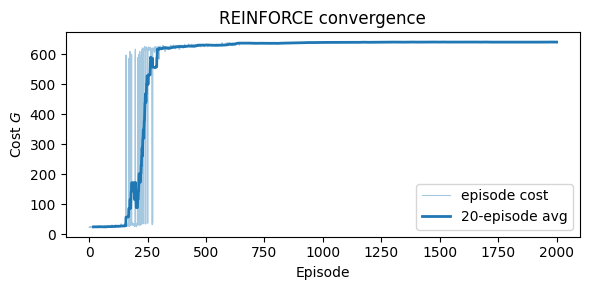

In [7]:
figure(figsize=(6, 3))
plot(cost_history, 'C0', alpha=0.4, lw=0.8, label='episode cost')
# Smooth with a running average
w = 20
smooth = np.convolve(cost_history, np.ones(w)/w, mode='valid')
plot(np.arange(w-1, len(cost_history)), smooth, 'C0', lw=2, label=f'{w}-episode avg')
xlabel('Episode');  ylabel('Cost $G$')
title('REINFORCE convergence')
legend();  tight_layout();  show()


## 8. Policy Evaluation

Average cost over 20 episodes to get a reliable performance estimate.

In [8]:
def evaluate(pol, n_episodes=20, seed=0):
    np.random.seed(seed)
    costs = [rollout(pol, deterministic=True)[2] for _ in range(n_episodes)]
    return np.mean(costs), np.std(costs)

mean_cost, std_cost = evaluate(policy)
print(f'Mean cost over 20 episodes: G = {mean_cost:.2f} ± {std_cost:.2f}')


KeyboardInterrupt: 

## 9. Final Policy Performance

Roll out the trained policy deterministically ($T_c = \mu$) to visualize setpoint tracking.

In [ ]:
_, Ca_out, T_out, Tc_out, cost_out = rollout(policy, deterministic=True, collect=True)
# G_t = cost-to-go: suffix sum, so G[0] = total episode cost, G[T] = 0
G_t = np.concatenate([np.cumsum(cost_out[::-1])[::-1], [0]])

fig, axes = subplots(4, 1, figsize=(7, 9), sharex=True)

axes[0].plot(t, Ca_out, 'C0');  axes[0].step(t, Ca_sp, 'k--', lw=1.2)
axes[0].set_ylabel(r'$c_A$ / (mol m$^{-3}$)');  axes[0].legend(['policy', 'setpoint'])

axes[1].plot(t, T_out, 'C1');  axes[1].step(t, T_sp, 'k--', lw=1.2)
axes[1].set_ylabel('$T$ / K')

axes[2].step(t[1:], Tc_out, 'C2')
axes[2].set_ylabel('$T_c$ / K')

axes[3].plot(t, G_t, 'C3')
axes[3].set_ylabel('$G_t$');  axes[3].set_xlabel('Time / min')

suptitle('Trained REINFORCE policy — CSTR setpoint tracking', y=1.01)
tight_layout();  show()